In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Dataset Generation

In [ ]:
np.random.seed(42)

N = 3000

x1 = np.random.uniform(-2, 2, (N,1))
x2 = np.random.uniform(-2, 2, (N,1))

X = np.hstack([x1, x2])

# Target rule
y = ((x1**2 + x2**2) > 1.5).astype(float)

In [ ]:
# 70/ 15/ 15 split
train_end = int(0.7 * N)
val_end = int(0.85 * N)

X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val = X[train_end:val_end], y[train_end:val_end]
X_test, y_test = X[val_end:], y[val_end:]

Activations

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_grad(a):
    return a * (1 - a)

def relu(z):
    return np.maximum(0, z)

def relu_grad(z):
    return (z > 0).astype(float)

loss and metrices

In [ ]:
def bce_loss(y, y_hat):
    eps = 1e-8
    y_hat = np.clip(y_hat, eps, 1 - eps)
    return -np.mean(y * np.log(y_hat) + (1-y)*np.log(1-y_hat))

def accuracy(y, y_hat):
    preds = (y_hat >= 0.5).astype(float)
    return np.mean(preds == y)

Dense Network Class

In [ ]:
class DenseNetwork:
    def __init__(self, layer_sizes, activation="relu", optimizer="sgd", lr=0.01):

        self.L = len(layer_sizes) - 1
        self.lr = lr
        self.activation_type = activation
        self.optimizer = optimizer

        self.W = []
        self.b = []
        self.vW = []
        self.vb = []

        for i in range(self.L):
            W = np.random.randn(layer_sizes[i], layer_sizes[i+1]) * 0.1
            b = np.zeros((1, layer_sizes[i+1]))

            self.W.append(W)
            self.b.append(b)

            self.vW.append(np.zeros_like(W))
            self.vb.append(np.zeros_like(b))


    def forward(self, X):
        self.A = [X]
        self.Z = []

        for i in range(self.L - 1):

            Z = self.A[-1] @ self.W[i] + self.b[i]
            self.Z.append(Z)

            if self.activation_type == "relu":
                A = relu(Z)
            else:
                A = sigmoid(Z)

            self.A.append(A)

        # Output layer (sigmoid)
        Z = self.A[-1] @ self.W[-1] + self.b[-1]
        self.Z.append(Z)
        A = sigmoid(Z)
        self.A.append(A)

        return A


    def backward(self, y):

        grads_W = []
        grads_b = []

        m = len(y)
        y_hat = self.A[-1]

        dA = y_hat - y

        for i in reversed(range(self.L)):

            dW = self.A[i].T @ dA / m
            db = np.sum(dA, axis=0, keepdims=True) / m

            grads_W.insert(0, dW)
            grads_b.insert(0, db)

            if i > 0:
                dZ = dA @ self.W[i].T

                if self.activation_type == "relu":
                    dA = dZ * relu_grad(self.Z[i-1])
                else:
                    dA = dZ * sigmoid_grad(self.A[i])

        return grads_W, grads_b


    def update(self, grads_W, grads_b):

        beta = 0.9

        for i in range(self.L):

            if self.optimizer == "momentum":

                self.vW[i] = beta*self.vW[i] + self.lr*grads_W[i]
                self.vb[i] = beta*self.vb[i] + self.lr*grads_b[i]

                self.W[i] -= self.vW[i]
                self.b[i] -= self.vb[i]

            else:  # SGD
                self.W[i] -= self.lr * grads_W[i]
                self.b[i] -= self.lr * grads_b[i]


    def gradient_norm(self, grads_W):
        total = 0
        for g in grads_W:
            total += np.sum(g**2)
        return np.sqrt(total)


Training function

In [ ]:
def train_model(model, epochs=500):

    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    grad_norms = []

    for epoch in range(epochs):

        # Forward
        y_hat = model.forward(X_train)

        # Loss
        loss = bce_loss(y_train, y_hat)

        # Backward
        grads_W, grads_b = model.backward(y_train)

        # Gradient norm
        grad_norms.append(model.gradient_norm(grads_W))

        # Update
        model.update(grads_W, grads_b)

        # Validation
        val_hat = model.forward(X_val)
        val_loss = bce_loss(y_val, val_hat)

        train_losses.append(loss)
        val_losses.append(val_loss)
        train_accs.append(accuracy(y_train, y_hat))
        val_accs.append(accuracy(y_val, val_hat))

        if epoch % 100 == 0:
            print(f"Epoch {epoch}, Train Loss {loss:.4f}, Val Loss {val_loss:.4f}")

    return train_losses, val_losses, train_accs, val_accs, grad_norms


In [ ]:
#example
model = DenseNetwork(
    layer_sizes=[2, 8, 8, 8, 8, 1],  # 5-layer
    activation="relu",
    optimizer="momentum",
    lr=0.01
)

train_losses, val_losses, train_accs, val_accs, grad_norms = train_model(model)

Epoch 0, Train Loss 0.6931, Val Loss 0.6926
Epoch 100, Train Loss 0.5954, Val Loss 0.6187
Epoch 200, Train Loss 0.5951, Val Loss 0.6198
Epoch 300, Train Loss 0.5951, Val Loss 0.6198
Epoch 400, Train Loss 0.5951, Val Loss 0.6198


In [ ]:
test_hat = model.forward(X_test)

print("\nTest Accuracy:", accuracy(y_test, test_hat))
print("Test Loss:", bce_loss(y_test, test_hat))


Test Accuracy: 0.7355555555555555
Test Loss: 0.5783089553060496


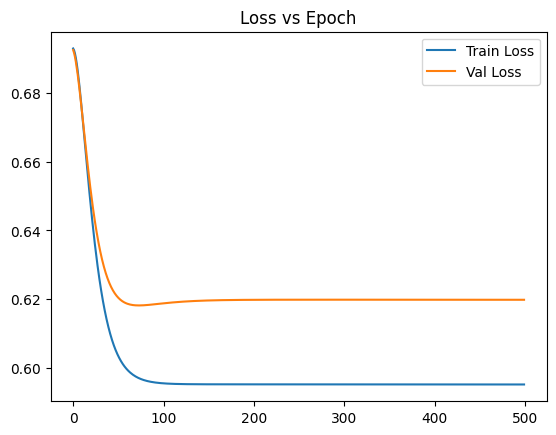

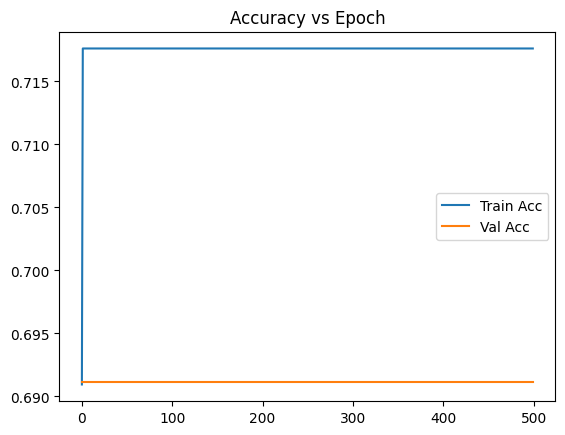

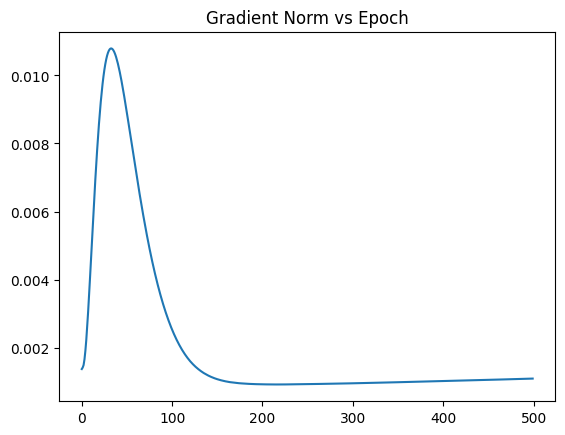

In [ ]:
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss vs Epoch")
plt.show()

plt.figure()
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend()
plt.title("Accuracy vs Epoch")
plt.show()

plt.figure()
plt.plot(grad_norms)
plt.title("Gradient Norm vs Epoch")
plt.show()